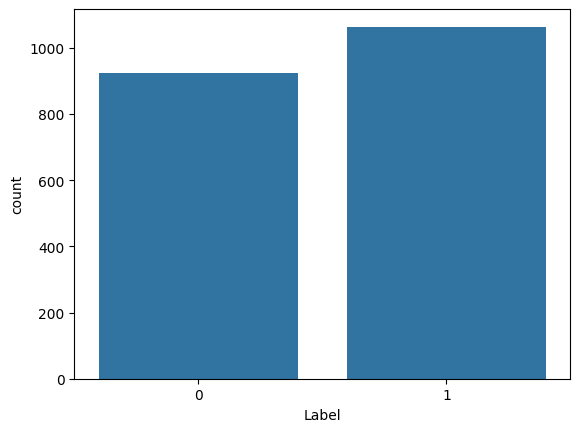

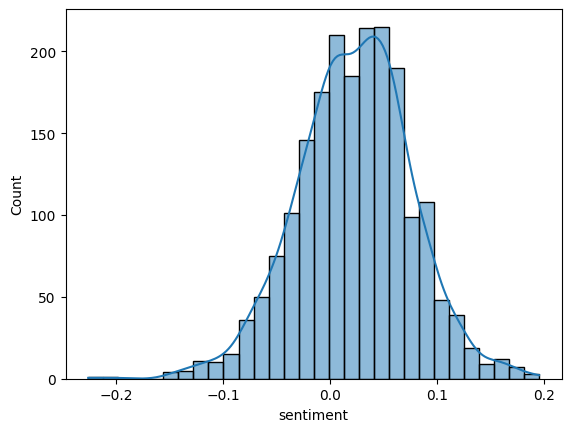

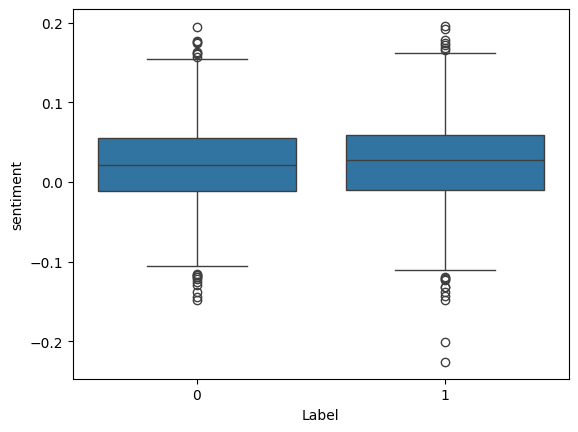

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("final_dataset.csv")

df["Label"] = (df["Close"].shift(-1) > df["Close"]).astype(int)

sns.countplot(x=df["Label"])
plt.show()

sns.histplot(df["sentiment"], bins=30, kde=True)
plt.show()

sns.boxplot(x=df["Label"], y=df["sentiment"])
plt.show()

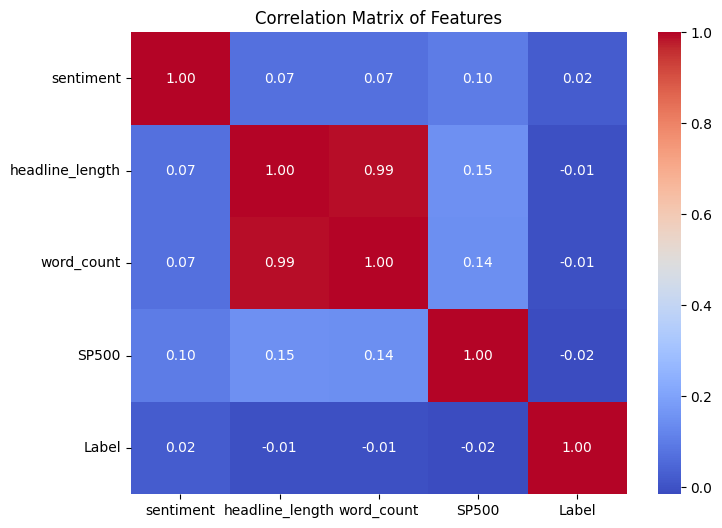

In [2]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
# Select only numerical columns for correlation
numerical_cols = df[['sentiment', 'headline_length', 'word_count', 'SP500', 'Label']]
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()


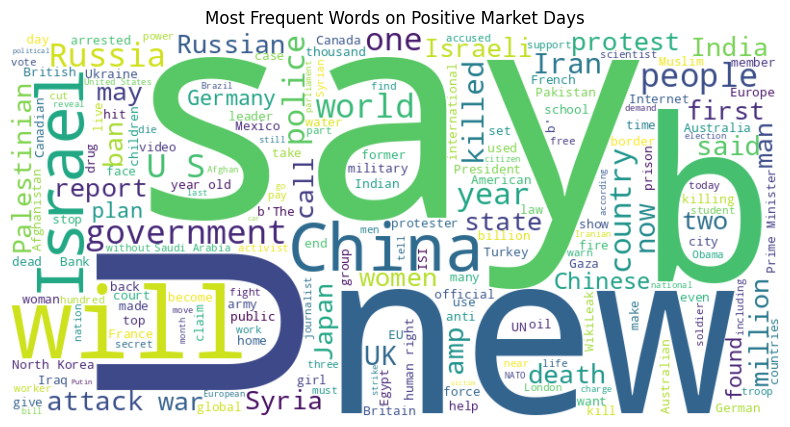

In [3]:
from wordcloud import WordCloud

# Wordcloud for Positive Market Days (Label 1)
positive_news = " ".join(text for text in df[df['Label'] == 1]['News'])
wordcloud_pos = WordCloud(width=800, height=400, background_color='white').generate(positive_news)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.title("Most Frequent Words on Positive Market Days")
plt.axis('off')
plt.show()
